In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, StandardScaler)

from sklearn.metrics import ( mean_squared_error, r2_score, mean_absolute_error)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb


In [3]:
df = pd.read_csv("final_internship_data.csv")
df.shape

(4309, 26)

In [4]:
summary = []

duplicates = df.duplicated().sum()

for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100

    summary.append([
        col,
        df[col].dtype,
        null_count,
        df[col].nunique()])

summary_df = pd.DataFrame(
    summary,
    columns=["Column", "Type", "Missing Values",  "Unique Values"])

print("Number of duplicate rows:", duplicates)

summary_df

Number of duplicate rows: 0


,Column,Type,Missing Values,Unique Values
0,User ID,object,0,4309
1,User Name,object,0,4198
2,Driver Name,object,0,4163
3,Car Condition,object,0,4
4,Weather,object,0,5
5,Traffic Condition,object,0,3
6,key,object,0,1809
7,fare_amount,float64,0,270
8,pickup_datetime,object,0,4304
9,pickup_longitude,float64,0,4062


In [5]:
df['fare_amount'].value_counts()

#df['Driver Name'].value_counts()

,count
fare_amount,
6.50,206
4.50,182
8.50,171
5.70,138
10.50,121
...,...
26.10,1
30.04,1
27.70,1


###############################################

In [6]:
#deleting

columns_to_drop = ['Driver Name', 'User Name', 'key','User ID']
df = df.drop(columns=columns_to_drop)

In [7]:
# فصل ال target

target = "fare_amount"
y = df[target]
X = df.drop(columns=[target])

####train - test before preproc.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature engineerimg

In [9]:
#Feature Engineering of time-s


df['Times of day'] = pd.cut(df['hour'],bins=[-1,6,12,18,24],labels=['Night','Morning','Afternoon','Evening'])

df['Peak hours'] = df['hour'].isin([7,8,9,16,17,18]).astype(int)

df['IS weekend'] = df["weekday"].isin([4,5,6]).astype(int)


def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Fall'

df['month season'] = df['month'].apply(get_season)

df['distance_hour'] = df['distance'] * df['hour']


df = df.drop('pickup_datetime', axis=1)
df.head()

,Car Condition,Weather,Traffic Condition,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,...,lga_dist,sol_dist,nyc_dist,distance,bearing,Times of day,Peak hours,IS weekend,month season,distance_hour
0,Very Good,windy,Congested Traffic,4.5,-1.288826,0.710721,-1.288779,0.710563,1.0,17.0,...,14.342611,34.543548,27.572573,1.030764,-2.918897,Afternoon,1,0,Summer,17.522987
1,Excellent,cloudy,Flow Traffic,16.9,-1.291824,0.710546,-1.291182,0.711780,1.0,16.0,...,23.130775,15.125872,8.755732,8.450134,-0.375217,Afternoon,1,0,Winter,135.202138
2,Bad,stormy,Congested Traffic,5.7,-1.291242,0.711418,-1.291391,0.711231,2.0,0.0,...,19.865289,17.722624,9.847344,1.389525,2.599961,Night,0,0,Summer,0.000000
3,Very Good,stormy,Flow Traffic,7.7,-1.291319,0.710927,-1.291396,0.711363,1.0,4.0,...,21.063132,15.738963,7.703421,2.799270,0.133905,Night,0,1,Spring,11.197081
4,Bad,stormy,Congested Traffic,5.3,-1.290987,0.711536,-1.290787,0.711811,1.0,7.0,...,15.219339,23.732406,15.600745,1.999157,-0.502703,Morning,1,0,Spring,13.994098


##OUTLIERS

In [10]:
numeric_cols = ['fare_amount','distance','passenger_count','bearing','jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers, min={df[col].min()}, max={df[col].max()}")

fare_amount: 364 outliers, min=-2.9, max=180.0
distance: 339 outliers, min=0.0, max=8667.454421
passenger_count: 445 outliers, min=0.0, max=6.0
bearing: 0 outliers, min=-3.137797914, max=3.141592654
jfk_dist: 512 outliers, min=1.15699468, max=30128.50347
ewr_dist: 240 outliers, min=11.14297842, max=30162.99271
lga_dist: 184 outliers, min=2.886567203, max=30162.71881
sol_dist: 154 outliers, min=6.217406114, max=30154.81713
nyc_dist: 184 outliers, min=0.47865204, max=30157.70062


In [73]:
#handeling fare amount

df.loc[df['fare_amount'] < 0, 'fare_amount'] = np.nan
df['fare_amount'].fillna(df['fare_amount'].median(), inplace=True)

# حساب IQR
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df['high_fare_flag'] = (df['fare_amount'] > upper_bound).astype(int)

/tmp/ipykernel_322/2977681833.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fare_amount'].fillna(df['fare_amount'].median(), inplace=True)


In [12]:
#handeling distance
df['distance'] = df['distance'].clip(lower=0.1, upper=100)

#handeling passengers
df.loc[df['passenger_count'] == 0, 'passenger_count'] = np.nan
df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)

#handeling airports distance
airport_cols = ['jfk_dist','ewr_dist','lga_dist','sol_dist','nyc_dist']
for col in airport_cols:
    df[col] = df[col].clip(upper=200)

/tmp/ipykernel_322/582073973.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)


In [13]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,...,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing,Peak hours,IS weekend,distance_hour
count,4309.000000,4309.000000,4309.000000,4309.000000,4309.000000,4309.000000,4308.000000,4308.000000,4308.000000,4308.000000,...,4308.000000,4308.000000,4308.000000,4308.000000,4308.000000,4308.000000,4308.000000,4309.000000,4309.000000,4308.000000
mean,11.239754,-1.265015,0.696445,-1.264708,0.696458,1.644233,13.461235,15.745357,6.101903,3.023213,...,45.205207,39.044713,23.352819,22.638316,15.052365,3.407399,0.302730,0.287306,0.436760,219.436059
std,9.680419,0.183531,0.107269,0.184539,0.107266,1.267002,6.522069,8.705053,3.404550,1.971334,...,23.067457,24.085099,26.094016,26.511536,27.599153,5.256914,1.792821,0.452558,0.496042,5493.264901
min,0.010000,-1.299192,-1.291342,-1.299037,-1.291166,1.000000,0.000000,1.000000,1.000000,0.000000,...,1.156995,11.142978,2.886567,6.217406,0.478652,0.100000,-3.137798,0.000000,0.000000,0.000000
25%,6.000000,-1.291411,0.710938,-1.291395,0.710949,1.000000,9.000000,8.000000,3.000000,1.000000,...,41.405354,32.147092,17.159850,14.759052,6.995487,1.209286,-0.839021,0.000000,0.000000,11.800588
50%,8.500000,-1.291229,0.711266,-1.291201,0.711285,1.000000,14.000000,16.000000,6.000000,3.000000,...,42.530396,34.740632,19.641675,18.356774,10.436041,2.105156,-0.075333,0.000000,0.000000,25.207280
75%,12.500000,-1.290971,0.711516,-1.290909,0.711535,2.000000,19.000000,23.000000,9.000000,5.000000,...,43.816906,38.301759,22.253486,22.398144,14.469019,3.949444,2.155470,1.000000,1.000000,51.865160
max,180.000000,0.711249,0.721975,0.711376,0.716154,6.000000,23.000000,31.000000,12.000000,6.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,100.000000,3.141593,1.000000,1.000000,199300.146641


<Axes: xlabel='fare_amount'>

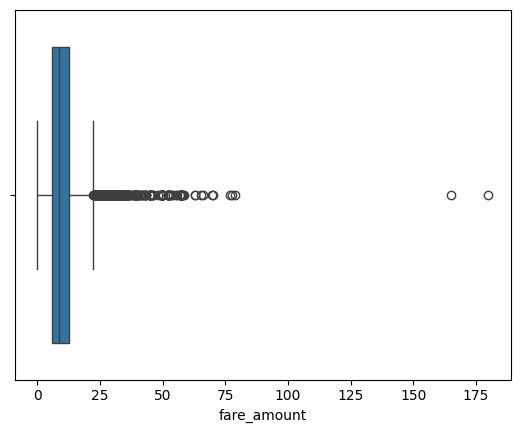

In [49]:
import seaborn as sns
sns.boxplot(x=df['fare_amount'])

In [14]:
#handeling missing values

numeric_cols = ['distance', 'bearing', 'dropoff_longitude', 'dropoff_latitude', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']
categorical_cols = ['car condition', 'weather', 'traffic condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

df = df.drop_duplicates()
df['fare_amount'] = df['fare_amount'].fillna(df['fare_amount'].median())

df.isnull().sum()

,0
Car Condition,0
Weather,0
Traffic Condition,0
fare_amount,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0
hour,0


##MODELING

In [15]:
#Linear Regression (One-Hot + Scaling)

lr_categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day', 'month season']
lr_num = ['distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']

X_lr = pd.get_dummies(df[lr_categorical + lr_num], drop_first=True)

# Scaling for numircal
scaler = StandardScaler()
X_lr[lr_num] = scaler.fit_transform(X_lr[lr_num])

y = df['fare_amount']
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

#calculat RMSE
y_pred_lr = lr_model.predict(X_test_lr)
rmse = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
print("Linear Regression RMSE:", rmse)

Linear Regression RMSE: 5.373758216092184


In [16]:
#Random Forest / XGBoost (Label Encoding للفئات، لا Scaling)

tree_categorical = ['Car Condition', 'Weather', 'Traffic Condition', 'year', 'month', 'day', 'weekday', 'hour', 'Times of day', 'month season']
tree_num = ['distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'passenger_count', 'distance_hour']

X_tree = df[tree_categorical + tree_num].copy()
for col in tree_categorical:
    le = LabelEncoder()
    X_tree[col] = le.fit_transform(X_tree[col])

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(X_tree, y, test_size=0.2, random_state=42)

In [51]:
# Random Forest

rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train_tree, y_train_tree)

# calculat RMSE
y_pred_rf = rf_model.predict(X_test_tree)
rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)


Random Forest RMSE: 3.96680416370323


In [18]:
#XGBoost

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_tree, y_train_tree)

# calculat RMSE
y_pred_xgb = xgb_model.predict(X_test_tree)
rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 4.771760629092672


###Evaluation

In [19]:
#تقييم Linear Regression

y_pred_lr = lr_model.predict(X_test_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
r2_lr = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Linear Regression
RMSE: 5.373758216092184
MAE: 3.3964859975037034
R2: 0.6225543016554627


In [20]:
#تقييم Random Forest

y_pred_rf = rf_model.predict(X_test_tree)

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))
mae_rf = mean_absolute_error(y_test_tree, y_pred_rf)
r2_rf = r2_score(y_test_tree, y_pred_rf)

print("Random Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Random Forest
RMSE: 3.96680416370323
MAE: 2.053802420153367
R2: 0.7943258284036558


In [21]:
#تقييم XGBoost

y_pred_xgb = xgb_model.predict(X_test_tree)

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_tree, y_pred_xgb)
r2_xgb = r2_score(y_test_tree, y_pred_xgb)

print("XGBoost")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R2:", r2_xgb)

XGBoost
RMSE: 4.771760629092672
MAE: 2.035420178990906
R2: 0.7023845073498245


###Comparison

In [22]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

print(results)

               Model      RMSE       MAE        R2
0  Linear Regression  5.373758  3.396486  0.622554
1      Random Forest  3.966804  2.053802  0.794326
2            XGBoost  4.771761  2.035420  0.702385


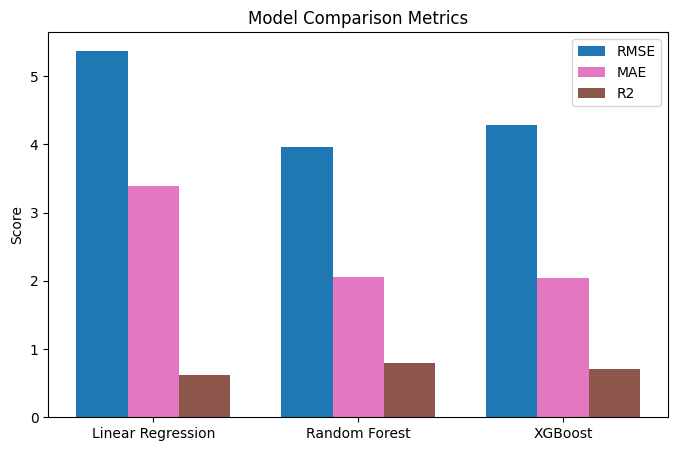

In [80]:
import matplotlib.pyplot as plt
import numpy as np

results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest","XGBoost"],
    "RMSE": [rmse_lr, rmse_rf, rmse_xgb],
    "MAE": [mae_lr, mae_rf, mae_xgb],
    "R2": [r2_lr, r2_rf, r2_xgb]
})

models = results['Model']
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, results['RMSE'], width, label='RMSE', color='#1f77b4')
plt.bar(x, results['MAE'], width, label='MAE', color='#e377c2')
plt.bar(x + width, results['R2'], width, label='R2', color='#8c564b')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison Metrics")
plt.legend()
plt.show()

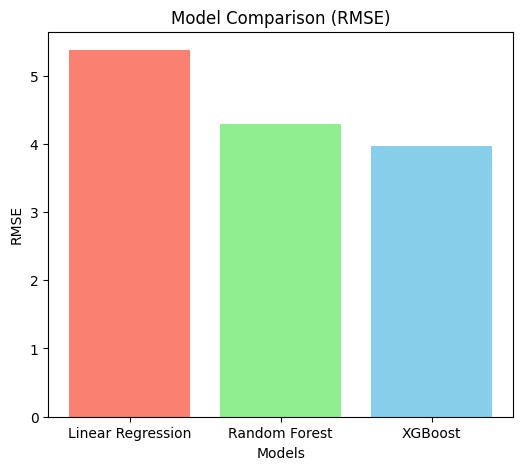

In [63]:
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest', 'XGBoost']
rmse_scores = [rmse_lr, rmse_xgb, rmse_rf]

colors = ['salmon', 'lightgreen', 'skyblue']

plt.figure(figsize=(6,5))
plt.bar(models, rmse_scores, color=colors)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Models")
plt.show()

##Validation

In [56]:
#cross validation

scores = cross_val_score(
    rf_model,
    X_tree,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

rmse_scores = -scores

print("RMSE for each fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE for each fold: [4.7615338  9.03037491 4.6630312  3.81156642 3.88159765]
Average RMSE: 5.229620795325923


In [55]:
#to more inhancing

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [53]:
#to enhance CV
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    rf_model,
    X_tree,
    y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

rmse_scores = -scores

print("RMSE per fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())

RMSE per fold: [4.00194684 6.35603139 4.63148797 6.73523853 4.88733666]
Average RMSE: 5.3224082780410455


<Axes: xlabel='fare_amount', ylabel='Count'>

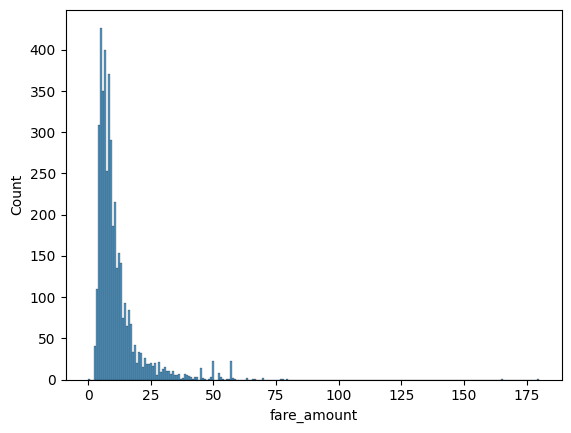

In [54]:
#may be a problem

sns.histplot(df['fare_amount'])

### (fare amount) showed a right-skewed distribution so we can use Transformation to improve model stability

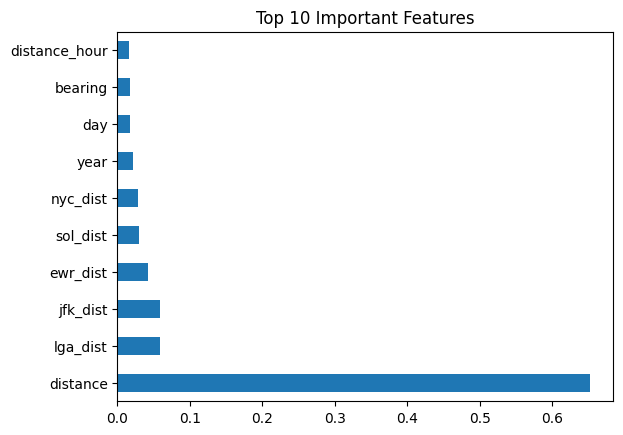

In [34]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feat_imp = pd.Series(importance, index=X_tree.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

## Hyperparameter Tuning

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_dist_rf = {
    "n_estimators": [100,200,300,400],
    "max_depth": [10,20,30,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt","log2"]
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_tree, y_train_tree)

print("Best RF Parameters:", rf_random.best_params_)

Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}


In [40]:
best_rf = rf_random.best_estimator_

y_pred_rf = best_rf.predict(X_test_tree)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse_rf = np.sqrt(mean_squared_error(y_test_tree, y_pred_rf))

print("Tuned Random Forest RMSE:", rmse_rf)

Tuned Random Forest RMSE: 3.880998659947487


In [41]:
#xgboost

from xgboost import XGBRegressor

xgb = XGBRegressor(objective="reg:squarederror", random_state=42)

param_dist_xgb = {
    "n_estimators": [200,400,600],
    "max_depth": [3,5,7,10],
    "learning_rate": [0.01,0.05,0.1],
    "subsample": [0.7,0.8,1],
    "colsample_bytree": [0.7,0.8,1]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train_tree, y_train_tree)

print("Best XGB Parameters:", xgb_random.best_params_)

Best XGB Parameters: {'subsample': 1, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [43]:
best_xgb = xgb_random.best_estimator_

y_pred_xgb = best_xgb.predict(X_test_tree)

rmse_xgb = np.sqrt(mean_squared_error(y_test_tree, y_pred_xgb))

print("Tuned XGBoost RMSE:", rmse_xgb)

Tuned XGBoost RMSE: 4.2867741513902855


                 Model      RMSE
2        XGBoost Tuned  3.966804
1  Random Forest Tuned  4.286774
0    Linear Regression  5.373758


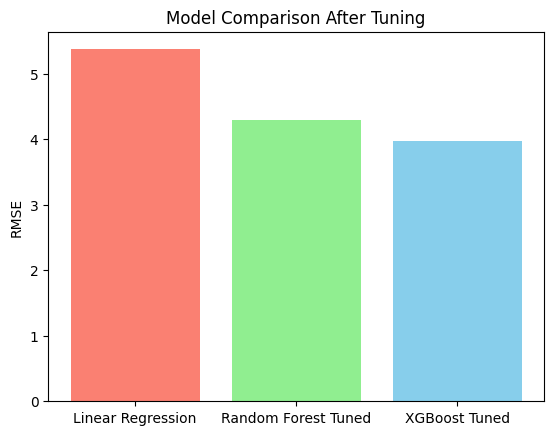

In [66]:
results = pd.DataFrame({
    "Model": ["Linear Regression","Random Forest Tuned","XGBoost Tuned"],
    "RMSE": [rmse_lr, rmse_xgb, rmse_rf]
})

print(results.sort_values("RMSE"))

import matplotlib.pyplot as plt
colors = ['salmon', 'lightgreen', 'skyblue']

plt.bar(results["Model"], results["RMSE"], color=colors)
plt.title("Model Comparison After Tuning")
plt.ylabel("RMSE")
plt.show()

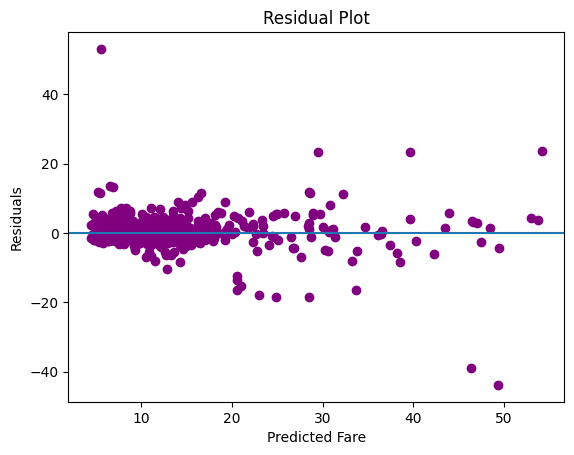

In [81]:
#Residual Analysis

residuals = y_test_tree - y_pred_xgb

plt.scatter(y_pred_xgb, residuals, color="Purple")
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.show()

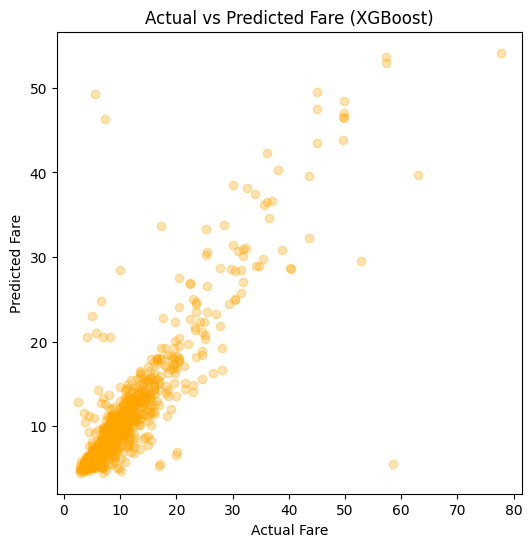

In [69]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_tree, y_pred_xgb, alpha=0.3, color="Orange")

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title("Actual vs Predicted Fare (XGBoost)")

plt.show()